In [4]:
!pip install tf-levenberg-marquardt

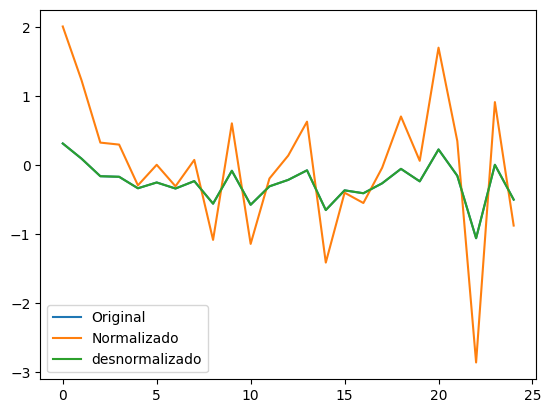

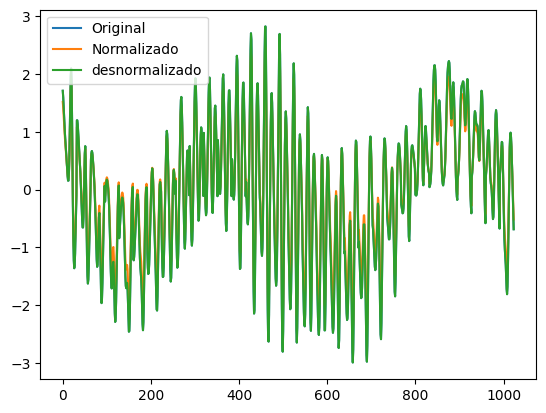

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepaths, grid):
    x, y, z = peaks(grid)
    z_pred_total = np.zeros_like(z).ravel()
    for filepath in filepaths:
        z_pred = pd.read_excel(filepath, usecols=['Z_pred']).squeeze('columns').to_numpy()
        z_pred_total += z_pred
    z_residuo= z.flatten() - (z_pred_total)
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_residuo}
    df = pd.DataFrame(data)
    return df
 
def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()

arquivos_25 = [
    "25_model_13_2_14.xlsx",
    "25_model_12_6_0.xlsx",
    "25_model_33_7_2.xlsx"
]
arquivos_1000 = [
    "1000_model_13_2_14.xlsx",
    "1000_model_12_6_0.xlsx",
    "1000_model_33_7_2.xlsx"
]
df_25 = create_dataframe_(arquivos_25, grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(arquivos_1000,grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [6]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=mse_loss,
            metrics=['mse']
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
            loss=mse_loss
        )
        return self.lm_model

In [7]:
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 
import plotly.figure_factory as ff
import plotly.offline as py
from scipy.spatial import Delaunay
import plotly.graph_objs as go
import os


class Rebuild:
    def __init__(self):
        self.df = pd.read_excel(f"better_results.xlsx")        
        self.sup_input, self.sup_output = split_df(df_1000_norm)

    def LoadModelWeights(self, model, fileName):        
        path = f"content/models/{fileName}.keras"
        model.load_weights(path)

    def LoadPrevDataset(self, fileName):
        fileName = fileName.replace("model", "dataset")
        pos = fileName.rfind("_")
        path = f"content/dataset/{fileName[:pos]}.pkl" 
        with open(path, 'rb') as f:
            _data, _train, _vt, _val, _test = pickle.load(f)
        self._data, self._train, self._vt, self._val, self._test = _data, _train, _vt, _val, _test    
    
    def setArchitecture(self, _hidden_sizes, _pg, _lr):
        shuffler = ShuffleArchitecture(input_size = 2,
                                    hidden_sizes = _hidden_sizes,
                                    output_size = 1,
                                    act_h = 'tanh',
                                    act_o = 'linear',
                                    param_reg = _pg)
        shuffler.set_architecture()
        return(shuffler.create_model(_lr))            

    def getArchitecture(self, architecture):
        hidden_size = [int(x) for x in architecture.split("[")[1].split("]")[0].split(", ")]
        regularizer = float(architecture.split("regularizer=")[1].split(",")[0])
        learning_rate = float(architecture.split("learning_rate=")[1])
        return hidden_size, regularizer, learning_rate

    def PlotResults(self, original_values, predicted_values):
        titles = ['Original vs. Preditos (Completo)',
                    'Original vs. Preditos (Teste)',
                    'Original vs. Preditos (Validação)',
                    'Original vs. Preditos (Validação e Teste)']
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        for i, ax in enumerate(axes.flat):
            ax.plot(original_values[i], label='Original')
            ax.plot(predicted_values[i], label='Preditos')
            ax.set_title(titles[i])
            ax.legend()
        plt.tight_layout()
        plt.show()


    def predictResults(self, idx=-1):
        pred = self.lm_model.predict(self._data[0]).flatten()
        test_pred = self.lm_model.predict(self._test[0]).flatten()
        val_pred = self.lm_model.predict(self._val[0]).flatten()
        vt_pred = self.lm_model.predict(self._vt[0]).flatten()
        sup_pred = self.lm_model.predict(self.sup_input).flatten()

        # Calculando as metricas com a saida desnormalizada
        pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
        test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
        val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
        vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
        sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

        out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
        test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
        val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
        vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))
        sup_denorm = out_scaler.inverse_transform(self.sup_output.reshape(-1, 1))

        original_values = [out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm]
        predicted_values = [pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm]

        if (idx != -1):
            self.RecalcMetrics(idx,
                                out_denorm, test_denorm, val_denorm, vt_denorm, sup_denorm,
                                pred_denorm, test_pred_denorm, val_pred_denorm, vt_pred_denorm, sup_pred_denorm)            
        return (original_values, predicted_values)

    def rebuildFullNet(self, model):
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            if model == file_model:
                hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
                self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
                self.LoadModelWeights(self.lm_model, file_model)
                self.LoadPrevDataset(file_model)
                original_values, predicted_values = self.predictResults()
                self.PlotResults(original_values, predicted_values)

    def create_dataset(self, input, output):
        input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
        output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
        dataset = tf.data.Dataset.from_tensor_slices((input, output))
        dataset = dataset.shuffle(len(input))
        dataset = dataset.batch(1000).cache()
        dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
        return (dataset, input, output)

    def LoadNewDataset(self):
        x = np.linspace(-2, 2, 6)
        y = np.linspace(-2, 2, 6)
        x, y = np.meshgrid(x, y)
        z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
        x = x.flatten()
        y = y.flatten()
        z = z.flatten()
        input = np.vstack([x,y]).T
        output = np.array(z)
        dataset = pd.DataFrame(input, columns=['x', 'y'])
        dataset['z'] = output
       # dataset, input, output = self.create_dataset(input, output)
        #dataset= pd.DataFrame(input,output)
        return (input, dataset)
    

    def mean_std(self, df):
        df_out = df.iloc[:, 2:]
        print(df)
        mean = df_out.mean(axis=1)
        std = df_out.std(axis=1)
        df["media"] = mean
        df["desvio padrao"] = std
        display(df)
        df.to_excel('content/results.xlsx', index=False)

    def TestNewData(self):
        input, df = self.LoadNewDataset()
        for file_model, architecture in zip(self.df["model"], self.df["Architecture"]):
            hidden_size, regularizer, learning_rate = self.getArchitecture(architecture)
            self.lm_model = self.setArchitecture(hidden_size, regularizer, learning_rate)
            self.LoadModelWeights(self.lm_model, file_model)
            pred = self.lm_model.predict(input).flatten()
            pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
            df[file_model] = pred_denorm
        self.mean_std(df)
        df.to_excel
            
                


In [8]:
Rebuilder = Rebuild()
Rebuilder.TestNewData()

2/2 [==============================] - 0s 6ms/step


/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2/2 [==============================] - 0s 4ms/step


/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2/2 [==============================] - 0s 3ms/step


...

2/2 [==============================] - 0s 3ms/step


/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



2/2 [==============================] - 0s 3ms/step
      x    y         z  model_22_7_6  model_22_7_7  model_22_7_5  \
0  -2.0 -2.0  0.046835      3.168582      3.168105      3.169434   
1  -1.2 -2.0 -0.193496      3.649814      3.663909      3.634421   
2  -0.4 -2.0 -3.152882      0.948023      0.916274      0.982465   
3   0.4 -2.0 -4.659211      0.371349      0.358623      0.385829   
4   1.2 -2.0 -1.313652      0.312884      0.306841      0.319880   
5   2.0 -2.0 -0.061640     -0.252012     -0.252485     -0.251802   
6  -2.0 -1.2  0.008297      0.514891      0.517877      0.511917   
7  -1.2 -1.2  0.997322      1.773067      1.773272      1.772795   
8  -0.4 -1.2 -0.232491      0.070881      0.052015      0.091751   
9   0.4 -1.2 -4.183030      0.299274      0.300791      0.297680   
10  1.2 -1.2 -0.534835     -0.436138     -0.444550     -0.426831   
11  2.0 -1.2  0.274603      0.535071      0.498452      0.574661   
12 -2.0 -0.4 -0.947252     -1.557777     -1.564502     -1.549781 

/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:144: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:131: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_2716035/1735587813.py:

,x,y,z,model_22_7_6,model_22_7_7,model_22_7_5,model_29_7_14,model_29_7_15,model_29_7_13,model_22_7_4,...,model_23_2_17,model_15_6_21,model_29_7_2,model_33_7_2,model_1_4_2,model_31_3_9,model_15_6_20,model_23_1_13,media,desvio padrao
0,-2.0,-2.0,0.046835,3.168582,3.168105,3.169434,3.402263,3.404783,3.396615,3.170701,...,0.921164,1.504241,2.968408,0.014353,1.802961,1.425842,1.490624,-0.236374,1.965638,1.390820
1,-1.2,-2.0,-0.193496,3.649814,3.663909,3.634421,1.773168,1.739027,1.805421,3.617671,...,1.419815,1.546246,1.865147,1.331986,1.613494,1.222280,1.542434,0.949175,1.969371,1.359606
2,-0.4,-2.0,-3.152882,0.948023,0.916274,0.982465,2.298984,2.290461,2.306906,1.019700,...,0.581840,0.844002,2.198790,-0.226774,1.119110,0.909043,0.837643,0.141664,0.975877,1.017806
3,0.4,-2.0,-4.659211,0.371349,0.358623,0.385829,0.672059,0.678859,0.666109,0.402327,...,0.535971,0.182732,0.631131,-0.088844,1.077596,0.822368,0.178545,1.437452,0.824617,0.790672
4,1.2,-2.0,-1.313652,0.312884,0.306841,0.319880,1.198348,1.209616,1.187467,0.327975,...,1.684536,-0.291210,1.068306,2.282876,2.166217,1.237788,-0.303898,1.939553,1.176730,0.968973
5,2.0,-2.0,-0.061640,-0.252012,-0.252485,-0.251802,0.950941,0.956123,0.946334,-0.251852,...,1.257250,-0.437010,0.965819,0.451462,1.099251,0.632928,-0.428662,0.284793,0.378616,0.617879
6,-2.0,-1.2,0.008297,0.514891,0.517877,0.511917,2.799267,2.829049,2.767322,0.509116,...,0.473042,1.063521,2.181919,-0.398757,0.462553,0.858354,1.070595,-1.203590,0.704579,0.850834
7,-1.2,-1.2,0.997322,1.773067,1.773272,1.772795,1.061409,1.073551,1.046969,1.772464,...,0.489800,1.069307,0.660161,0.068689,0.551693,0.626889,1.060713,0.306138,0.838695,0.509781
8,-0.4,-1.2,-0.232491,0.070881,0.052015,0.091751,1.220307,1.225584,1.214984,0.114767,...,0.715042,0.658188,1.162418,0.247059,0.529534,0.380688,0.655176,1.176073,0.541185,0.494561
9,0.4,-1.2,-4.183030,0.299274,0.300791,0.297680,-0.305587,-0.305646,-0.305792,0.296020,...,1.025597,0.028998,-0.321474,0.934560,0.962529,0.716840,0.035233,1.210354,0.579991,0.642714
